In [18]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
 
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_theme(style="whitegrid")
 
print("All libraries imported successfully!")

All libraries imported successfully!


In [19]:
CSV_PATH = "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
 
df = pd.read_csv(CSV_PATH)
 
print("Shape          :", df.shape)
print("Columns        :", list(df.columns))
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDescriptive Stats:\n", df.describe())
print("\nFirst 5 Rows:\n", df.head())

Shape          : (2640, 12)
Columns        : ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Data Types:
 Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

Missing Values:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Descriptive

EXPLORATORY DATA ANALYSIS


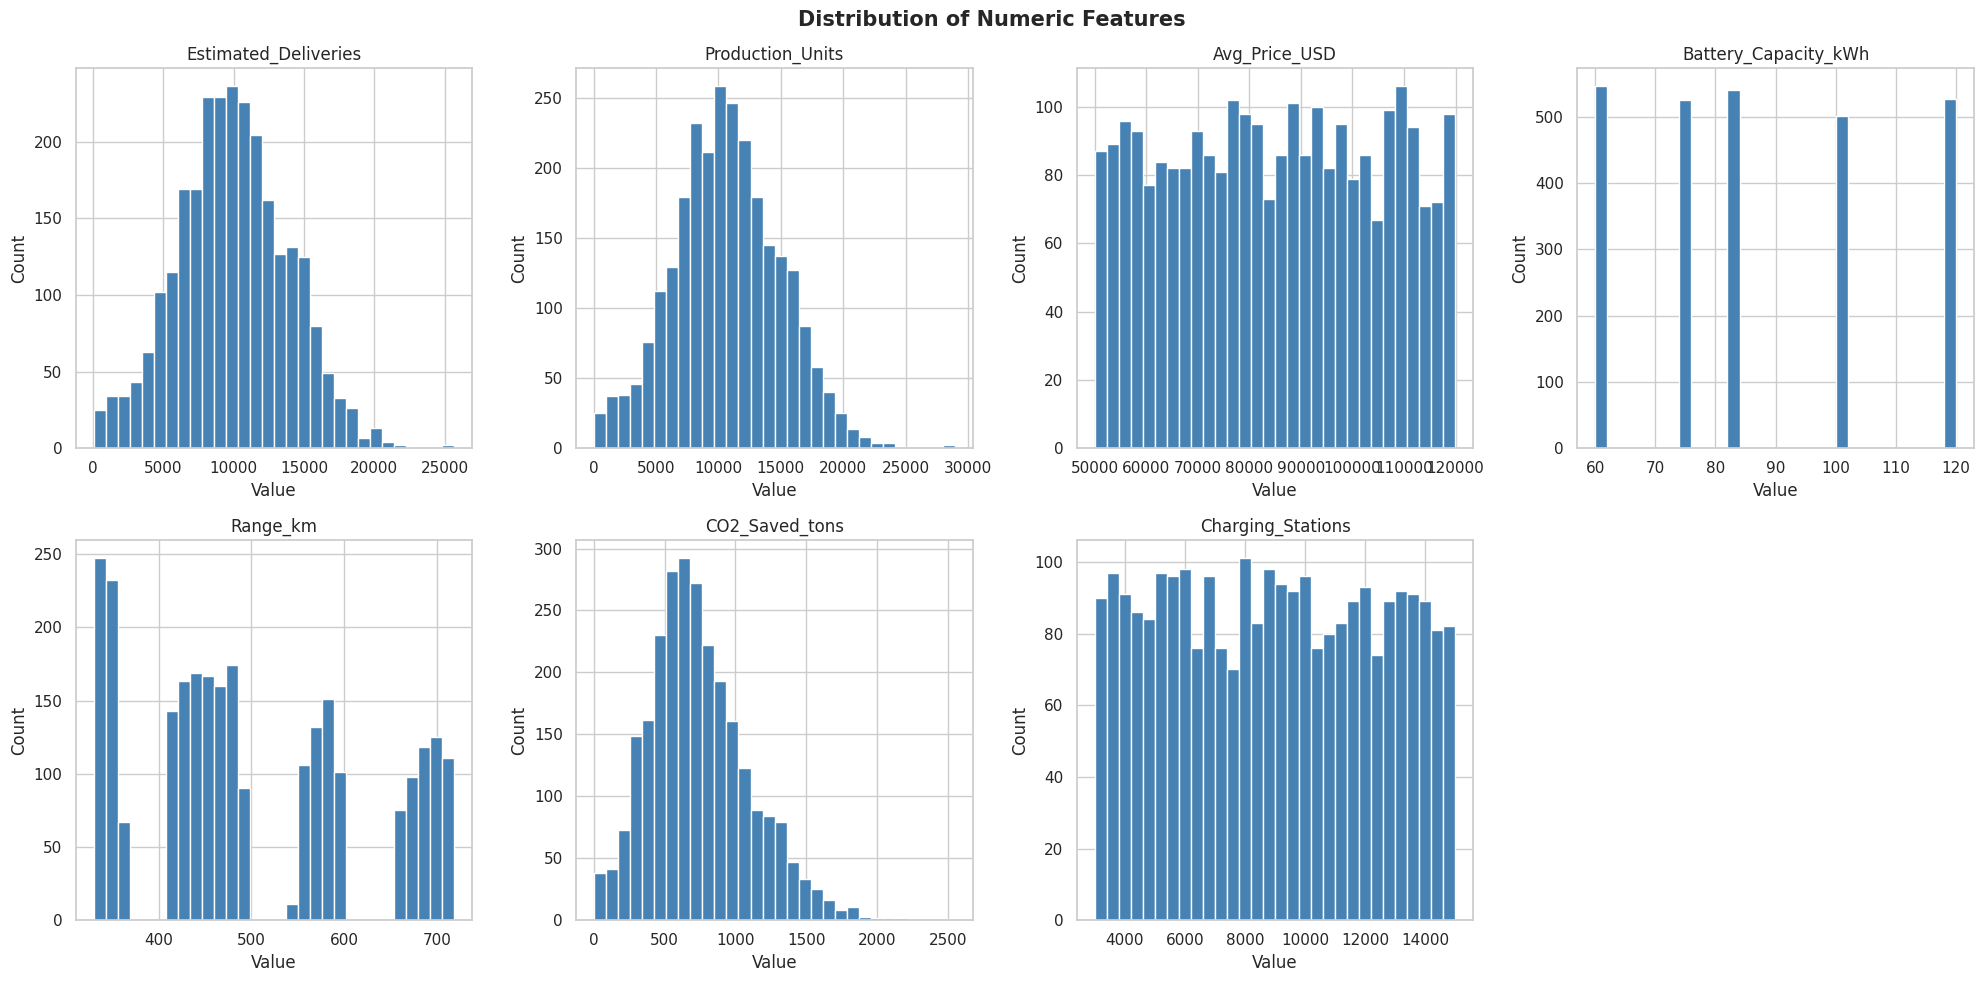

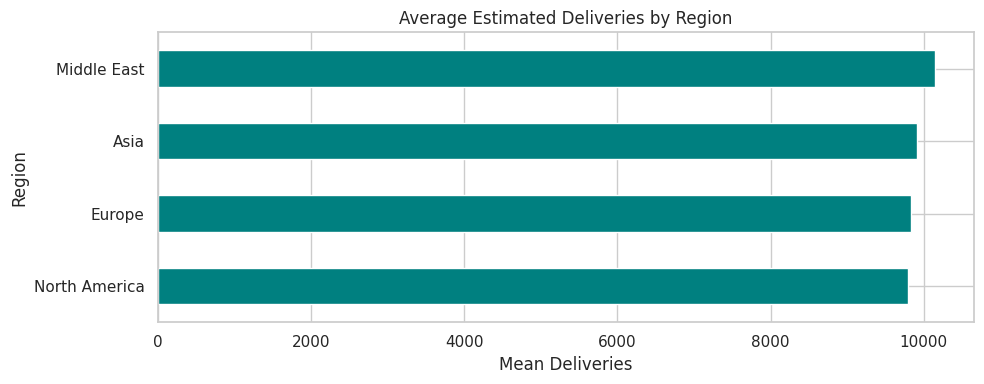

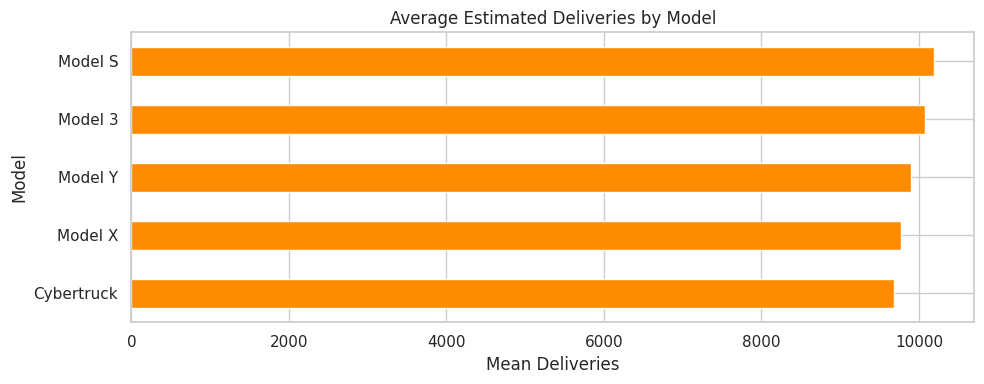

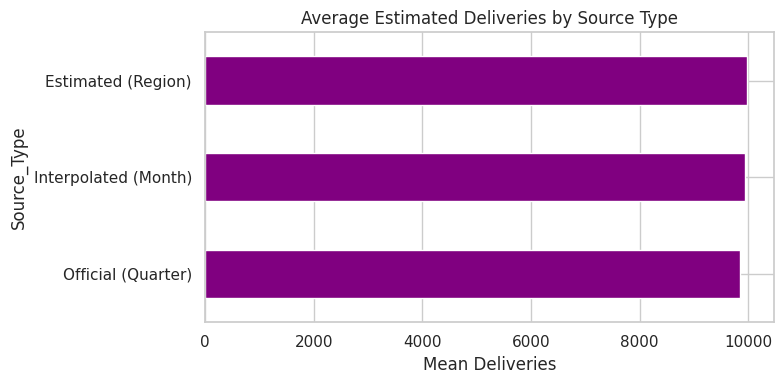

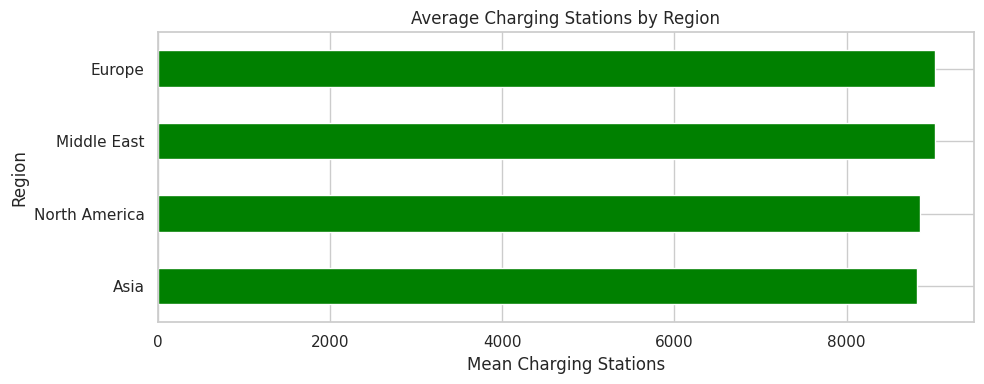

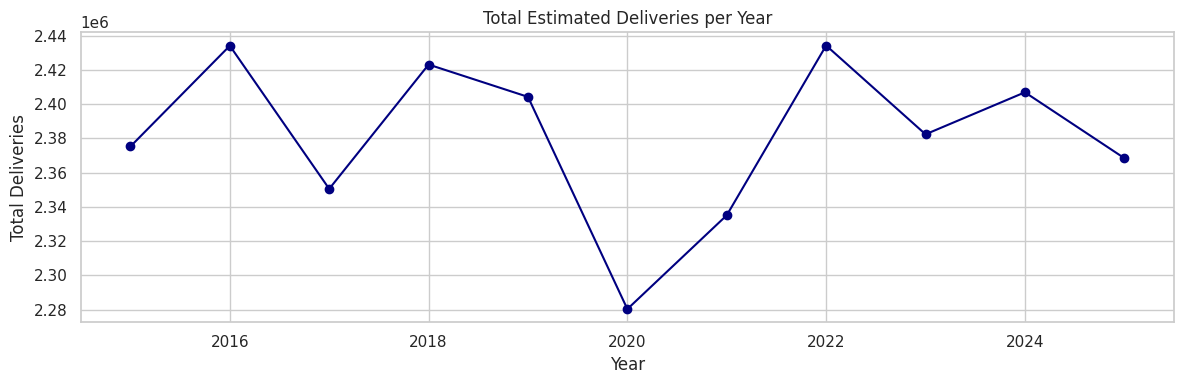

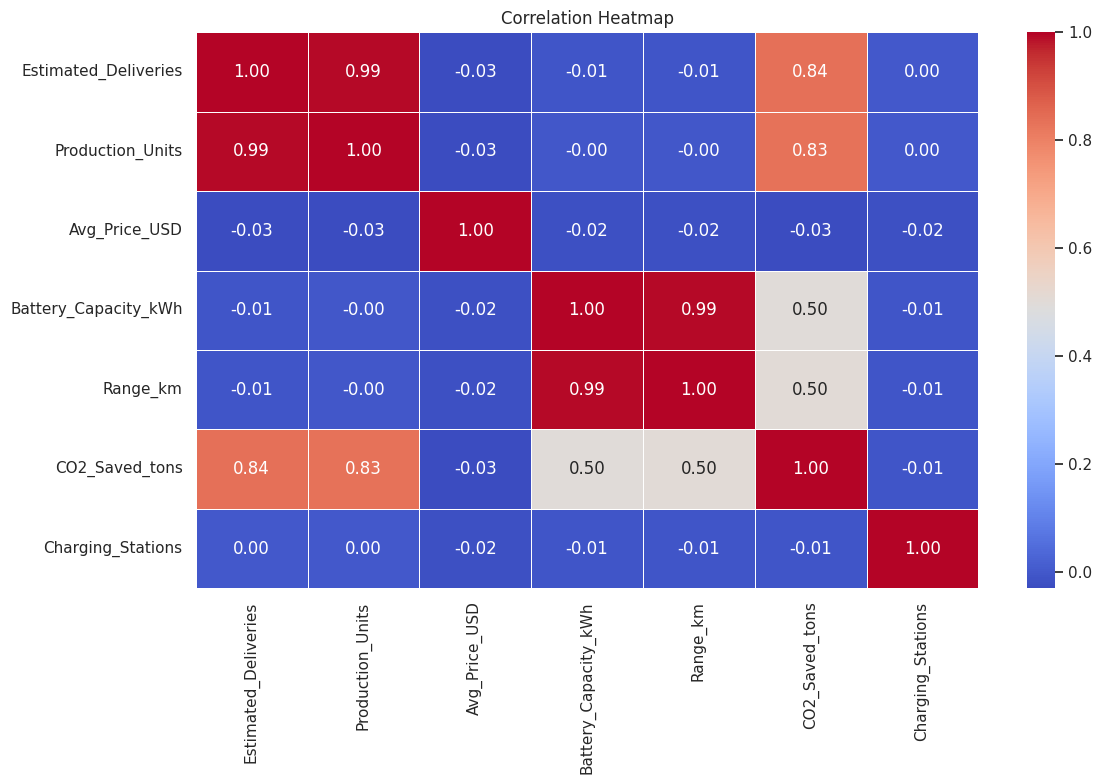

EDA complete.



In [20]:
print("=" * 55)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 55)
 
num_cols = ["Estimated_Deliveries", "Production_Units",
            "Avg_Price_USD", "Battery_Capacity_kWh",
            "Range_km", "CO2_Saved_tons", "Charging_Stations"]
 

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Distribution of Numeric Features", fontsize=15, fontweight="bold")
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
axes.flatten()[-1].set_visible(False)   # hide the empty 8th subplot
plt.tight_layout()
plt.show()
 

plt.figure(figsize=(10, 4))
df.groupby("Region")["Estimated_Deliveries"].mean().sort_values().plot(
    kind="barh", color="teal")
plt.title("Average Estimated Deliveries by Region")
plt.xlabel("Mean Deliveries")
plt.tight_layout()
plt.show()
 

plt.figure(figsize=(10, 4))
df.groupby("Model")["Estimated_Deliveries"].mean().sort_values().plot(
    kind="barh", color="darkorange")
plt.title("Average Estimated Deliveries by Model")
plt.xlabel("Mean Deliveries")
plt.tight_layout()
plt.show()
 

plt.figure(figsize=(8, 4))
df.groupby("Source_Type")["Estimated_Deliveries"].mean().sort_values().plot(
    kind="barh", color="purple")
plt.title("Average Estimated Deliveries by Source Type")
plt.xlabel("Mean Deliveries")
plt.tight_layout()
plt.show()
 

plt.figure(figsize=(10, 4))
df.groupby("Region")["Charging_Stations"].mean().sort_values().plot(
    kind="barh", color="green")
plt.title("Average Charging Stations by Region")
plt.xlabel("Mean Charging Stations")
plt.tight_layout()
plt.show()
 

plt.figure(figsize=(12, 4))
df.groupby("Year")["Estimated_Deliveries"].sum().plot(marker="o", color="navy")
plt.title("Total Estimated Deliveries per Year")
plt.ylabel("Total Deliveries")
plt.tight_layout()
plt.show()
 

plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
 
print("EDA complete.\n")

In [21]:
print("=" * 55)
print("PREPROCESSING & FEATURE ENGINEERING")
print("=" * 55)
 
df_ml = df.copy()
 

le_region = LabelEncoder()
le_model  = LabelEncoder()
le_source = LabelEncoder()
 
df_ml["Region_enc"]      = le_region.fit_transform(df_ml["Region"])
df_ml["Model_enc"]       = le_model.fit_transform(df_ml["Model"])
df_ml["Source_Type_enc"] = le_source.fit_transform(df_ml["Source_Type"])
 

df_ml["Year_norm"]  = df_ml["Year"] - df_ml["Year"].min()
df_ml["Month_sin"]  = np.sin(2 * np.pi * df_ml["Month"] / 12)
df_ml["Month_cos"]  = np.cos(2 * np.pi * df_ml["Month"] / 12)
 

df_ml["Price_per_kWh"]       = df_ml["Avg_Price_USD"] / df_ml["Battery_Capacity_kWh"]
df_ml["Efficiency_ratio"]    = df_ml["Range_km"] / df_ml["Battery_Capacity_kWh"]
df_ml["Stations_per_Region"] = df_ml["Charging_Stations"] / (df_ml["Region_enc"] + 1)
 
FEATURES = [
    "Year_norm", "Month_sin", "Month_cos",
    "Region_enc", "Model_enc", "Source_Type_enc",
    "Production_Units", "Avg_Price_USD",
    "Battery_Capacity_kWh", "Range_km",
    "CO2_Saved_tons", "Charging_Stations",
    "Price_per_kWh", "Efficiency_ratio", "Stations_per_Region"
]
TARGET = "Estimated_Deliveries"
 
X = df_ml[FEATURES]
y = df_ml[TARGET]
 
print(f"Features used : {len(FEATURES)}")
print(f"Target        : {TARGET}")
print(f"X shape       : {X.shape}\n")

PREPROCESSING & FEATURE ENGINEERING
Features used : 15
Target        : Estimated_Deliveries
X shape       : (2640, 15)



REGRESSION MODELING

Linear Regression
  CV R² : 0.9902 ± 0.0007
  MAE   : 310.38  |  RMSE : 383.87  |  R² : 0.9901

Ridge
  CV R² : 0.9902 ± 0.0007
  MAE   : 310.15  |  RMSE : 383.97  |  R² : 0.9901

Lasso
  CV R² : 0.9902 ± 0.0007
  MAE   : 309.79  |  RMSE : 383.10  |  R² : 0.9902

Random Forest
  CV R² : 0.9878 ± 0.0016
  MAE   : 333.72  |  RMSE : 422.63  |  R² : 0.9880

Gradient Boosting
  CV R² : 0.9888 ± 0.0014
  MAE   : 327.68  |  RMSE : 404.33  |  R² : 0.9890

★  Best model: Lasso  (R² = 0.9902)


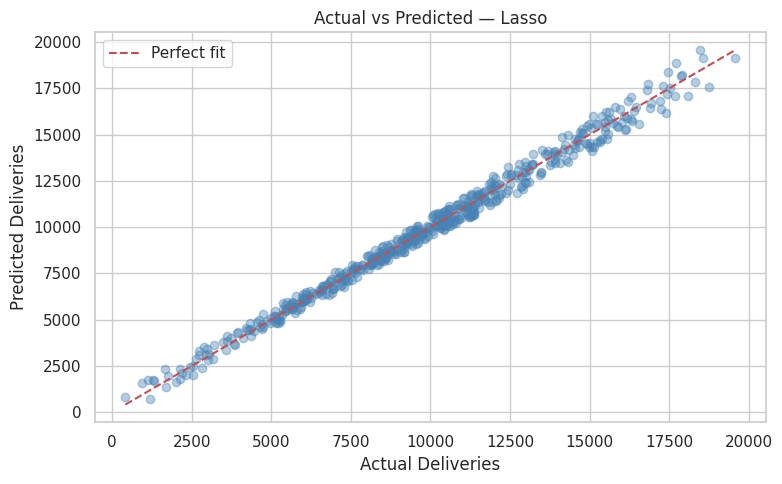

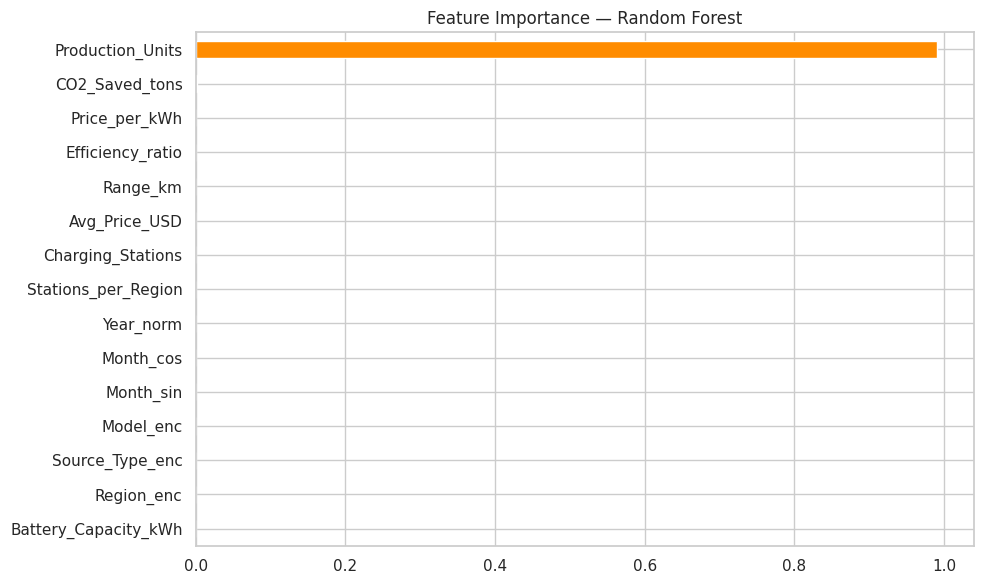

In [22]:
print("=" * 55)
print("REGRESSION MODELING")
print("=" * 55)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
 
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
 
models = {
    "Linear Regression" : LinearRegression(),
    "Ridge"             : Ridge(alpha=1.0),
    "Lasso"             : Lasso(alpha=1.0, max_iter=10000),
    "Random Forest"     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=100, random_state=42),
}
 
results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)
 
for name, model in models.items():
    Xtr, Xte = (X_train, X_test) if "Forest" in name or "Boosting" in name \
               else (X_train_sc, X_test_sc)
 
    cv_scores = cross_val_score(model, Xtr, y_train, cv=kf, scoring="r2", n_jobs=-1)
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
 
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
 
    results[name] = {"model": model, "MAE": mae, "RMSE": rmse,
                     "R2": r2, "CV_mean": cv_scores.mean(),
                     "CV_std": cv_scores.std(), "preds": preds}
 
    print(f"\n{name}")
    print(f"  CV R² : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  MAE   : {mae:.2f}  |  RMSE : {rmse:.2f}  |  R² : {r2:.4f}")
 
best_name = max(results, key=lambda k: results[k]["R2"])
best      = results[best_name]
print(f"\n★  Best model: {best_name}  (R² = {best['R2']:.4f})")
 

plt.figure(figsize=(8, 5))
plt.scatter(y_test, best["preds"], alpha=0.4, color="steelblue")
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="Perfect fit")
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title(f"Actual vs Predicted — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()
 

rf = results["Random Forest"]["model"]
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi.plot(kind="barh", color="darkorange", figsize=(10, 6))
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

In [23]:
print("\n" + "=" * 55)
print("HYPERPARAMETER TUNING (Random Forest)")
print("=" * 55)
 
param_grid = {
    "n_estimators"     : [100, 200],
    "max_depth"        : [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf" : [1, 2],
}
 
gs = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                  param_grid, cv=3, scoring="r2", n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)
 
tuned_preds = gs.best_estimator_.predict(X_test)
print(f"\nBest Params : {gs.best_params_}")
print(f"Best CV R²  : {gs.best_score_:.4f}")
print(f"Tuned R²    : {r2_score(y_test, tuned_preds):.4f}")
print(f"Tuned MAE   : {mean_absolute_error(y_test, tuned_preds):.2f}")
print(f"Tuned RMSE  : {np.sqrt(mean_squared_error(y_test, tuned_preds)):.2f}")


HYPERPARAMETER TUNING (Random Forest)
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Params : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV R²  : 0.9875
Tuned R²    : 0.9879
Tuned MAE   : 334.72
Tuned RMSE  : 424.36



TIME SERIES FORECASTING
Time Series — Test MAE  : 10393.67
Time Series — Test RMSE : 13546.41
Time Series — Test R²   : -0.1211


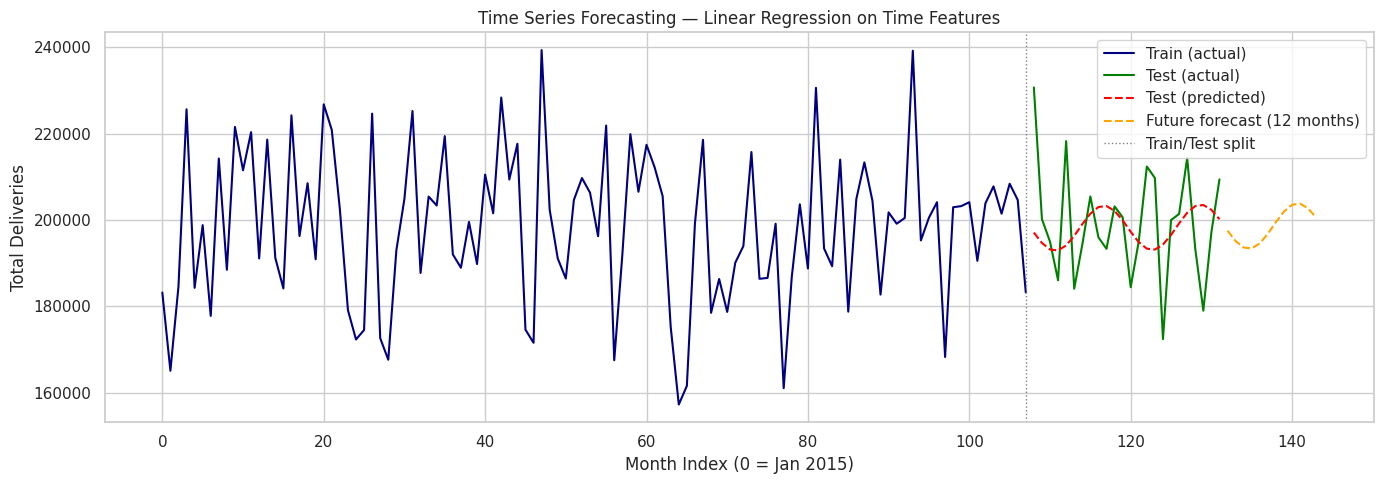

In [24]:
print("\n" + "=" * 55)
print("TIME SERIES FORECASTING")
print("=" * 55)
 

ts = (df.groupby(["Year", "Month"])["Estimated_Deliveries"]
        .sum().reset_index()
        .sort_values(["Year", "Month"]).reset_index(drop=True))
 
ts["t"]         = np.arange(len(ts))
ts["Month_sin"] = np.sin(2 * np.pi * ts["Month"] / 12)
ts["Month_cos"] = np.cos(2 * np.pi * ts["Month"] / 12)
ts["t_squared"] = ts["t"] ** 2
 

train_ts = ts[ts["Year"] < 2024]
test_ts  = ts[ts["Year"] >= 2024]
 
ts_features = ["t", "t_squared", "Month_sin", "Month_cos"]
 
ts_model = LinearRegression()
ts_model.fit(train_ts[ts_features], train_ts["Estimated_Deliveries"])
 
test_preds = ts_model.predict(test_ts[ts_features])
 

last_t      = ts["t"].max()
last_month  = ts["Month"].iloc[-1]
future_rows = []
for i in range(1, 13):
    future_t   = last_t + i
    future_mon = ((last_month - 1 + i) % 12) + 1
    future_rows.append({
        "t"        : future_t,
        "t_squared": future_t ** 2,
        "Month_sin": np.sin(2 * np.pi * future_mon / 12),
        "Month_cos": np.cos(2 * np.pi * future_mon / 12),
    })
 
future_df    = pd.DataFrame(future_rows)
future_preds = ts_model.predict(future_df[ts_features])
 

mae_ts  = mean_absolute_error(test_ts["Estimated_Deliveries"], test_preds)
rmse_ts = np.sqrt(mean_squared_error(test_ts["Estimated_Deliveries"], test_preds))
r2_ts   = r2_score(test_ts["Estimated_Deliveries"], test_preds)
 
print(f"Time Series — Test MAE  : {mae_ts:.2f}")
print(f"Time Series — Test RMSE : {rmse_ts:.2f}")
print(f"Time Series — Test R²   : {r2_ts:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(train_ts["t"], train_ts["Estimated_Deliveries"],
         label="Train (actual)", color="navy", linewidth=1.5)
plt.plot(test_ts["t"], test_ts["Estimated_Deliveries"],
         label="Test (actual)", color="green", linewidth=1.5)
plt.plot(test_ts["t"], test_preds,
         label="Test (predicted)", color="red", linestyle="--", linewidth=1.5)
plt.plot(future_df["t"], future_preds,
         label="Future forecast (12 months)", color="orange",
         linestyle="--", linewidth=1.5)
plt.axvline(x=train_ts["t"].max(), color="gray", linestyle=":", linewidth=1,
            label="Train/Test split")
plt.xlabel("Month Index (0 = Jan 2015)")
plt.ylabel("Total Deliveries")
plt.title("Time Series Forecasting — Linear Regression on Time Features")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
print("\n" + "=" * 55)
print("SUMMARY")
print("=" * 55)
 
summary = pd.DataFrame([
    {"Model": name, "Test R²": f"{v['R2']:.4f}",
     "Test MAE": f"{v['MAE']:.2f}", "Test RMSE": f"{v['RMSE']:.2f}",
     "CV R²": f"{v['CV_mean']:.4f} ± {v['CV_std']:.4f}"}
    for name, v in results.items()
])
print(summary.to_string(index=False))
print(f"\n★  Best regression model : {best_name}")
print(f"★  Time series Test R²   : {r2_ts:.4f}")
print("\n✓  Pipeline complete!")


SUMMARY
            Model Test R² Test MAE Test RMSE           CV R²
Linear Regression  0.9901   310.38    383.87 0.9902 ± 0.0007
            Ridge  0.9901   310.15    383.97 0.9902 ± 0.0007
            Lasso  0.9902   309.79    383.10 0.9902 ± 0.0007
    Random Forest  0.9880   333.72    422.63 0.9878 ± 0.0016
Gradient Boosting  0.9890   327.68    404.33 0.9888 ± 0.0014

★  Best regression model : Lasso
★  Time series Test R²   : -0.1211

✓  Pipeline complete!
